In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.max_columns',None)
sns.set_theme(style="darkgrid")
print("Libarires Ready!")

Libarires Ready!


In [6]:
import zipfile

# Unzip the file first
with zipfile.ZipFile('netflix_titles.csv.zip', 'r') as zip_ref:
    zip_ref.extractall('.')

df=pd.read_csv("netflix_titles.csv")
print("Shape:",df.shape)
print("\nColumn Names:\n",df.columns.tolist())
df.head()

Shape: (8807, 12)

Column Names:
 ['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description']


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [7]:
#Checking missing values
print("Missing Values in Each Column:\n")
print(df.isnull().sum())

Missing Values in Each Column:

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64


In [15]:
#clean the data
#filling missing values
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')
df['rating'] = df['rating'].fillna('Not Rated')

#Drop rows where data_added is missing
df = df.dropna(subset=['date_added'])

#Extract year and month
df['date_added']=pd.to_datetime(df['date_added'])
df['year_added']=df['date_added'].dt.year
df['month_added']=df['date_added'].dt.month
print("Data Cleaned!")
print("New Shape:",df.shape)

AttributeError: Can only use .str accessor with string values!

In [11]:
#summary statistics
print("=== Basic Statistics===\n")
print("Total Titles:",len(df))
print("\nContent Type Count:")
print(df['type'].value_counts())
print("\nTop 5 Countries:")
print(df['country'].value_counts().head())

=== Basic Statistics===

Total Titles: 8797

Content Type Count:
type
Movie      6131
TV Show    2666
Name: count, dtype: int64

Top 5 Countries:
country
United States     2812
India              972
Unknown            830
United Kingdom     418
Japan              244
Name: count, dtype: int64


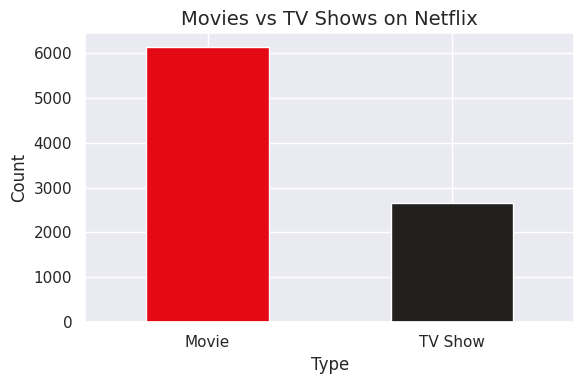

In [12]:
#Movies vs TV Shows
plt.figure(figsize=(6,4))
df['type'].value_counts().plot(kind='bar',color=['#E50914','#221F1F'])
plt.title("Movies vs TV Shows on Netflix",fontsize=14)
plt.xlabel("Type")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

/tmp/ipykernel_1386/645982022.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.values,y=top_countries.index,palette='Reds_r')


<function matplotlib.pyplot.show(close=None, block=None)>

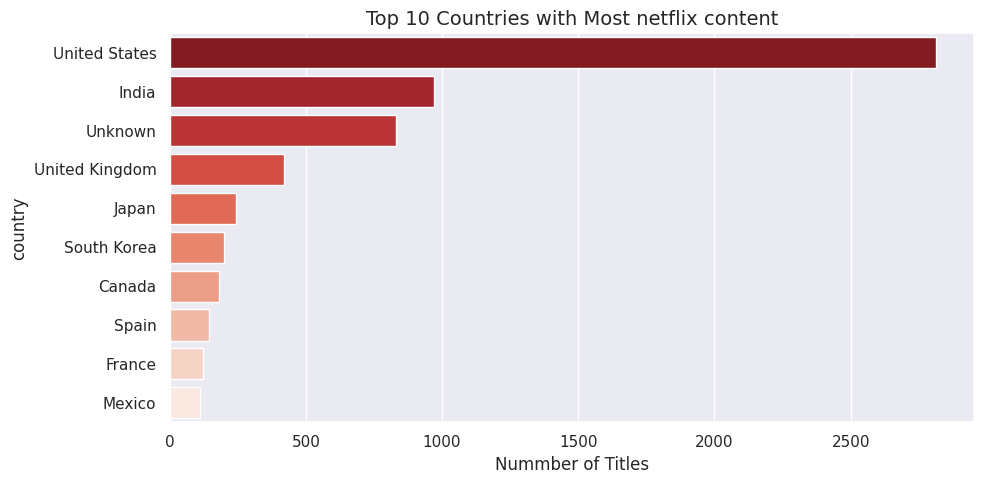

In [13]:
#showing Top 10 countries
top_countries=df['country'].value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_countries.values,y=top_countries.index,palette='Reds_r')
plt.title("Top 10 Countries with Most netflix content",fontsize=14)
plt.xlabel("Nummber of Titles")
plt.tight_layout()
plt.show

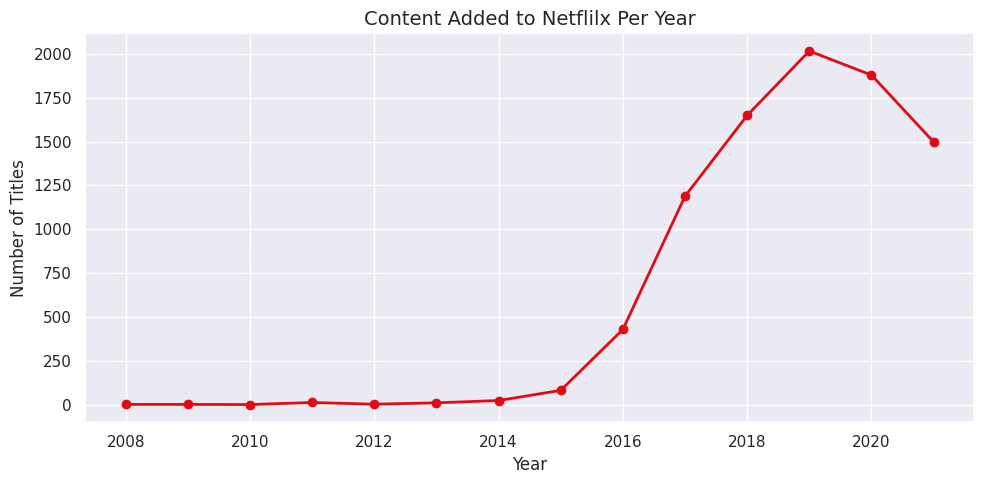

In [16]:
#Content Added per year
plt.figure(figsize=(10,5))
df['year_added'].value_counts().sort_index().plot(
    kind='line',marker='o',color='#E50914',linewidth=2
)
plt.title("Content Added to Netflilx Per Year",fontsize=14)
plt.xlabel("Year")
plt.ylabel("Number of Titles")
plt.tight_layout()
plt.show()

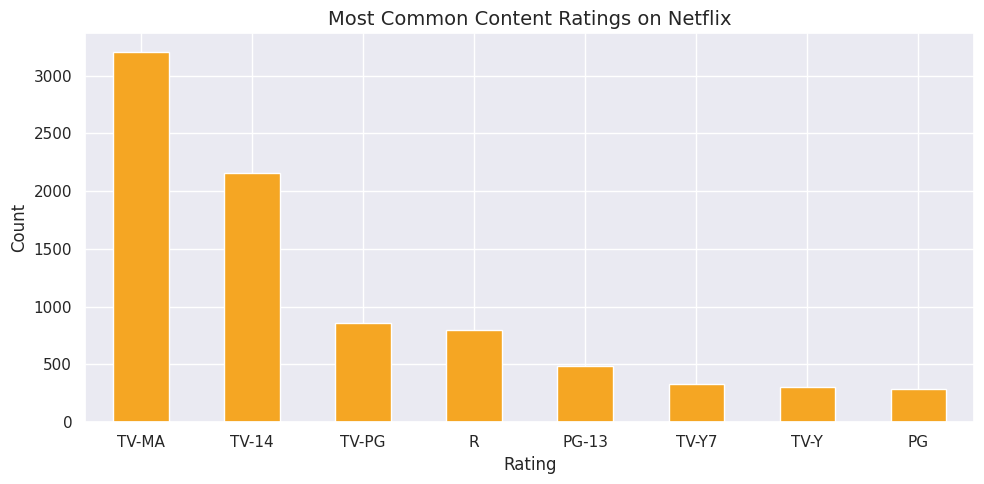

In [17]:
#Top Ratings
plt.figure(figsize=(10,5))
df['rating'].value_counts().head(8).plot(kind='bar',color='#F5A623')
plt.title("Most Common Content Ratings on Netflix",fontsize=14)
plt.xlabel("Rating")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [19]:
#key Insights
print("="*45)
print("     KEY INSIGHTS-NETFLIX EDA")
print("="*45)
print(f"\n Total Titles Analysed:{len(df)}")
print(f" Movies:{len(df[df['type']=='Movie'])}")
print(f" TV Shows:{len(df[df['type']=='TV Shoes'])}")
print(f" Top Contry:United States (2l818)")
print(f" Peak Year:2019")
print(f" Most Common Rating:TV-MA")
print("="*45)

     KEY INSIGHTS-NETFLIX EDA

 Total Titles Analysed:8797
 Movies:6131
 TV Shows:0
 Top Contry:United States (2l818)
 Peak Year:2019
 Most Common Rating:TV-MA
